In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/larbisck/nwpu-vhr-10")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Hamza Momen
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/larbisck/nwpu-vhr-10


100%|██████████| 73.3M/73.3M [00:05<00:00, 13.8MB/s]


In [17]:
import os
import shutil
import cv2

# ===== PATHS =====
BASE_DIR = "/content/nwpu-vhr-10/NWPU VHR-10 dataset"

GT_DIR  = os.path.join(BASE_DIR, "ground truth")
IMG_DIR = os.path.join(BASE_DIR, "positive image set")

OUT_DIR = "/content/oiltank_dataset"
IMG_OUT = os.path.join(OUT_DIR, "images")
LBL_OUT = os.path.join(OUT_DIR, "labels")

os.makedirs(IMG_OUT, exist_ok=True)
os.makedirs(LBL_OUT, exist_ok=True)


# ===== YOLO CONVERSION FUNCTION =====
def convert(size, box):
    w, h = size
    xmin, ymin, xmax, ymax = box
    x  = ((xmin + xmax) / 2) / w
    y  = ((ymin + ymax) / 2) / h
    bw = (xmax - xmin) / w
    bh = (ymax - ymin) / h
    return x, y, bw, bh


# ===== PREPROCESSING LOOP =====
count = 0

for file in os.listdir(GT_DIR):
    if not file.endswith(".txt"):
        continue

    img_name = file.replace(".txt", ".jpg")
    img_path = os.path.join(IMG_DIR, img_name)

    if not os.path.exists(img_path):
        continue

    img = cv2.imread(img_path)
    if img is None:
        continue

    h, w   = img.shape[:2]
    lines_out = []

    with open(os.path.join(GT_DIR, file)) as f:
        for line in f:
            line  = line.strip()
            if line == "":
                continue
            parts = line.replace("(", "").replace(")", "").split(",")
            parts = [p.strip() for p in parts if p.strip() != ""]
            if len(parts) != 5:
                continue
            xmin, ymin, xmax, ymax, cls = map(int, parts)
            if cls != 3:
                continue
            x, y, bw, bh = convert((w, h), (xmin, ymin, xmax, ymax))
            if not (0 <= x <= 1 and 0 <= y <= 1 and 0 <= bw <= 1 and 0 <= bh <= 1):
                continue
            lines_out.append(f"0 {x} {y} {bw} {bh}")

    if len(lines_out) == 0:
        continue

    shutil.copy(img_path, os.path.join(IMG_OUT, img_name))
    with open(os.path.join(LBL_OUT, img_name.replace(".jpg", ".txt")), "w") as f:
        f.write("\n".join(lines_out))
    count += 1

print(f"Done! {count} images with oil tanks saved.")

Done! 28 images with oil tanks saved.


In [18]:
# ===== DATASET =====
import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import os

class YOLODataset(Dataset):
    def __init__(self, img_dir, label_dir, S=20):
        self.img_dir   = img_dir
        self.label_dir = label_dir
        self.S         = S
        self.files     = sorted([f for f in os.listdir(img_dir) if f.endswith(".jpg")])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        name = self.files[idx]

        img = cv2.imread(os.path.join(self.img_dir, name))
        img = cv2.resize(img, (640, 640))
        img = torch.tensor(img).permute(2, 0, 1).float() / 255

        target     = torch.zeros((self.S, self.S, 5))
        label_path = os.path.join(self.label_dir, name.replace(".jpg", ".txt"))

        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    _, x, y, w, h = map(float, line.split())
                    i, j = int(x * self.S), int(y * self.S)
                    if i < self.S and j < self.S:
                        target[j, i] = torch.tensor([
                            x * self.S - i,
                            y * self.S - j,
                            w, h, 1
                        ])

        return img, target

In [19]:
# ===== MODEL BUILDING BLOCKS =====
import torch.nn as nn
import torch

# --- ConvBNSiLU ---
# The base unit of YOLOv5. Every conv in the network uses this.
# SiLU (Sigmoid Linear Unit) replaced ReLU in YOLOv5 for smoother gradients.
class ConvBNSiLU(nn.Module):
    def __init__(self, ci, co, k=3, s=1):
        super().__init__()
        self.m = nn.Sequential(
            nn.Conv2d(ci, co, k, s, k//2, bias=False),
            nn.BatchNorm2d(co, momentum=0.03, eps=1e-3),
            nn.SiLU(inplace=True))
    def forward(self, x):
        return self.m(x)


# --- CSPBlock ---
# Cross Stage Partial Block — the core YOLOv5 backbone unit.
# Splits the feature map into two paths:
#   path1: goes through bottleneck convolutions (learns features)
#   path2: skips directly (preserves original information)
# Both are concatenated and merged. This gives richer gradients
# and avoids redundant computation compared to a plain conv stack.
class CSPBlock(nn.Module):
    def __init__(self, ci, co, s=2):
        super().__init__()
        mid        = co // 2
        self.down  = ConvBNSiLU(ci, co, 3, s)
        self.path1 = nn.Sequential(
            ConvBNSiLU(co, mid, 1),
            ConvBNSiLU(mid, mid, 3),
            ConvBNSiLU(mid, mid, 3))
        self.path2 = ConvBNSiLU(co, mid, 1)
        self.merge = ConvBNSiLU(mid * 2, co, 1)

    def forward(self, x):
        x = self.down(x)
        return self.merge(torch.cat([self.path1(x), self.path2(x)], 1))


# --- SPPF ---
# Spatial Pyramid Pooling Fast.
# Stacks three 5x5 max-pools (effective sizes 5, 9, 13) and concatenates.
# Gives the model awareness of oil tanks at multiple zoom levels
# without adding extra convolution cost.
class SPPF(nn.Module):
    def __init__(self, c):
        super().__init__()
        mid       = c // 2
        self.cv1  = ConvBNSiLU(c, mid, 1)
        self.pool = nn.MaxPool2d(5, 1, 2)
        self.cv2  = ConvBNSiLU(mid * 4, c, 1)

    def forward(self, x):
        x  = self.cv1(x)
        p1 = self.pool(x)
        p2 = self.pool(p1)
        p3 = self.pool(p2)
        return self.cv2(torch.cat([x, p1, p2, p3], 1))


# --- YOLOv5Tiny ---
# Full model: Stem → CSP Backbone → SPPF → Detection Head
# Output: [B, S, S, 5]  where 5 = (cx_off, cy_off, w, h, objectness)
class YOLOv5Tiny(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem   = ConvBNSiLU(3,   16,  k=6, s=2)
        self.stage1 = CSPBlock(16,  32)
        self.stage2 = CSPBlock(32,  64)
        self.stage3 = CSPBlock(64,  128)
        self.stage4 = CSPBlock(128, 256)
        self.sppf   = SPPF(256)
        self.head   = nn.Conv2d(256, 5, 1)
        # Start objectness near zero so the model predicts
        # no objects everywhere at init — learns to activate gradually
        nn.init.constant_(self.head.bias[4], -4.6)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.sppf(x)
        x = torch.sigmoid(self.head(x))
        return x.permute(0, 2, 3, 1)   # [B,C,H,W] → [B,S,S,5]


# ===== MEASURE REAL GRID SIZE =====
# Run a dummy forward pass to get the actual S the model outputs.
# This avoids the grid size mismatch crash.
device = "cuda" if torch.cuda.is_available() else "cpu"
with torch.no_grad():
    _o = YOLOv5Tiny().to(device)(torch.zeros(1, 3, 640, 640).to(device))
S = _o.shape[1]
print(f"Grid size S = {S}")

Grid size S = 21


In [20]:
# ===== LOSS FUNCTION =====
import torch.nn.functional as F

def loss_fn(pred, target):
    obj   = target[..., 4] == 1
    noobj = ~obj

    # Objectness losses
    obj_loss   = (F.binary_cross_entropy(pred[...,4][obj],   target[...,4][obj])
                  if obj.any() else torch.tensor(0., device=pred.device))
    noobj_loss =  F.binary_cross_entropy(pred[...,4][noobj], target[...,4][noobj])

    # IoU box loss (replaces MSE — scale-invariant, better for small objects)
    if obj.any():
        B  = pred.shape[0]
        cg = torch.arange(S, device=pred.device).view(1, 1, S).expand(B, S, S)
        rg = torch.arange(S, device=pred.device).view(1, S, 1).expand(B, S, S)

        # Decode predicted boxes to full-image coordinates
        pb = torch.stack([(cg        + pred[..., 0]) / S,
                          (rg        + pred[..., 1]) / S,
                           pred[..., 2],
                           pred[..., 3]], dim=-1)

        # Decode target boxes to full-image coordinates
        tb = torch.stack([(cg.float() + target[..., 0]) / S,
                          (rg.float() + target[..., 1]) / S,
                           target[..., 2],
                           target[..., 3]], dim=-1)

        # Convert cx,cy,w,h → corners for IoU calculation
        px1, py1 = pb[obj][...,0]-pb[obj][...,2]/2, pb[obj][...,1]-pb[obj][...,3]/2
        px2, py2 = pb[obj][...,0]+pb[obj][...,2]/2, pb[obj][...,1]+pb[obj][...,3]/2
        tx1, ty1 = tb[obj][...,0]-tb[obj][...,2]/2, tb[obj][...,1]-tb[obj][...,3]/2
        tx2, ty2 = tb[obj][...,0]+tb[obj][...,2]/2, tb[obj][...,1]+tb[obj][...,3]/2

        iw    = (torch.min(px2,tx2) - torch.max(px1,tx1)).clamp(0)
        ih    = (torch.min(py2,ty2) - torch.max(py1,ty1)).clamp(0)
        inter = iw * ih
        union = (px2-px1)*(py2-py1) + (tx2-tx1)*(ty2-ty1) - inter + 1e-7
        box_loss = (1 - inter/union).mean()
    else:
        box_loss = torch.tensor(0., device=pred.device)

    return 5*box_loss + 5*obj_loss + 2*noobj_loss

In [28]:
# ===== DATALOADER & TRAINING =====
dataset = YOLODataset("/content/oiltank_dataset/images",
                      "/content/oiltank_dataset/labels",
                      S=S)

loader = DataLoader(dataset, batch_size=8, shuffle=True)

model = YOLOv5Tiny().to(device)
opt   = torch.optim.Adam(model.parameters(), lr=5e-5)

for epoch in range(200):
    total = 0
    for imgs, targets in loader:
        imgs, targets = imgs.to(device), targets.to(device)
        preds = model(imgs)
        loss  = loss_fn(preds, targets)
        opt.zero_grad()
        loss.backward()
        opt.step()
        total += loss.item()
    print(f"Epoch {epoch}: {total/len(loader):.4f}")


# ===== NMS =====
# Real suppression — removes overlapping boxes that describe the same object.
def nms(boxes, scores, thresh=0.45):
    order = scores.argsort(descending=True)
    keep  = []
    while order.numel() > 0:
        i = order[0].item()
        keep.append(i)
        if order.numel() == 1:
            break
        rest = order[1:]
        iw   = (boxes[rest,2].clamp(max=boxes[i,2]) - boxes[rest,0].clamp(min=boxes[i,0])).clamp(0)
        ih   = (boxes[rest,3].clamp(max=boxes[i,3]) - boxes[rest,1].clamp(min=boxes[i,1])).clamp(0)
        inter = iw * ih
        ai    = (boxes[i,2]-boxes[i,0])   * (boxes[i,3]-boxes[i,1])
        ar    = (boxes[rest,2]-boxes[rest,0]) * (boxes[rest,3]-boxes[rest,1])
        iou   = inter / (ai + ar - inter + 1e-7)
        order = rest[iou < thresh]
    return keep

Epoch 0: 26.9004
Epoch 1: 22.9684
Epoch 2: 19.2203
Epoch 3: 18.2325
Epoch 4: 17.4834
Epoch 5: 14.2729
Epoch 6: 13.3208
Epoch 7: 12.7122
Epoch 8: 12.0070
Epoch 9: 10.7978
Epoch 10: 9.6773
Epoch 11: 10.0619
Epoch 12: 8.9446
Epoch 13: 7.9449
Epoch 14: 8.1624
Epoch 15: 7.7165
Epoch 16: 7.4547
Epoch 17: 7.0894
Epoch 18: 7.0359
Epoch 19: 6.8831
Epoch 20: 6.5263
Epoch 21: 6.3716
Epoch 22: 6.5044
Epoch 23: 5.9564
Epoch 24: 5.9372
Epoch 25: 5.4929
Epoch 26: 5.5489
Epoch 27: 5.2657
Epoch 28: 5.0146
Epoch 29: 4.8949
Epoch 30: 5.0473
Epoch 31: 4.7089
Epoch 32: 4.4575
Epoch 33: 4.4923
Epoch 34: 4.7055
Epoch 35: 4.1509
Epoch 36: 4.1873
Epoch 37: 4.1679
Epoch 38: 4.2436
Epoch 39: 4.2965
Epoch 40: 4.0389
Epoch 41: 4.1003
Epoch 42: 3.9339
Epoch 43: 4.1903
Epoch 44: 3.9782
Epoch 45: 4.1845
Epoch 46: 3.9053
Epoch 47: 3.8574
Epoch 48: 3.7871
Epoch 49: 3.6960
Epoch 50: 3.6013
Epoch 51: 3.8022
Epoch 52: 3.5976
Epoch 53: 3.6761
Epoch 54: 3.5493
Epoch 55: 3.3317
Epoch 56: 3.4879
Epoch 57: 3.2858
Epoch 58: 3.4

Detected 76 boxes


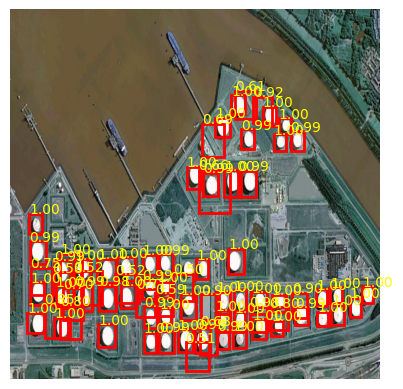

In [35]:
# ===== DECODE & VISUALISE =====
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def decode_predictions(pred, conf_thresh=0.65):
    boxes, scores = [], []
    for i in range(S):
        for j in range(S):
            conf = pred[i, j, 4].item()
            if conf < conf_thresh:
                continue
            x_cell, y_cell, w, h = pred[i, j, :4]
            x = (j + x_cell.item()) / S
            y = (i + y_cell.item()) / S
            x1, y1 = x - w/2, y - h/2
            x2, y2 = x + w/2, y + h/2
            boxes.append([x1, y1, x2, y2])
            scores.append(conf)

    if not boxes:
        return []

    bt    = torch.tensor(boxes)
    st    = torch.tensor(scores)
    keep  = nms(bt, st)
    # Return as [x, y, w, h, conf] for draw_boxes compatibility
    result = []
    for i in keep:
        x1,y1,x2,y2 = bt[i].tolist()
        result.append([(x1+x2)/2, (y1+y2)/2, x2-x1, y2-y1, st[i].item()])
    return result


def draw_boxes(img, boxes):
    img    = img.copy()
    h, w, _ = img.shape
    fig, ax = plt.subplots(1)
    ax.imshow(img)
    for box in boxes:
        x, y, bw, bh, conf = box
        xmin = (x - bw/2) * w
        ymin = (y - bh/2) * h
        rect = patches.Rectangle(
            (xmin, ymin), bw*w, bh*h,
            linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        ax.text(xmin, ymin, f"{conf:.2f}", color='yellow')
    plt.axis("off")
    plt.show()


def test_model(model, dataset, device):
    model.eval()
    idx    = torch.randint(0, len(dataset), (1,)).item()
    img, _ = dataset[idx]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))[0].cpu()
    img_np = img.permute(1, 2, 0).numpy()
    boxes  = decode_predictions(pred, conf_thresh=0.5)
    print(f"Detected {len(boxes)} boxes")
    draw_boxes(img_np, boxes)

test_model(model, dataset, device)